In [ ]:
# %pip install rouge-score

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

BLIP Epoch 9 Loss: 0.2250


BLIP Epoch 10: 100%|██████████| 132/132 [01:30<00:00,  1.45it/s]


BLIP Epoch 10 Loss: 0.2270
BLIP model saved!

Evaluating on validation set (val_loader)...


  3%|▎         | 1/34 [00:08<04:34,  8.32s/it]/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
100%|██████████| 34/34 [01:37<00:00,  2.86s/it]


Results saved.

📊 Validation Set Report Generation Metrics:
Avg BLEU:     0.5859
Avg METEOR:   0.4021
Avg ROUGE-1:  0.6780
Avg ROUGE-2:  0.1333
Avg ROUGE-L:  0.6676


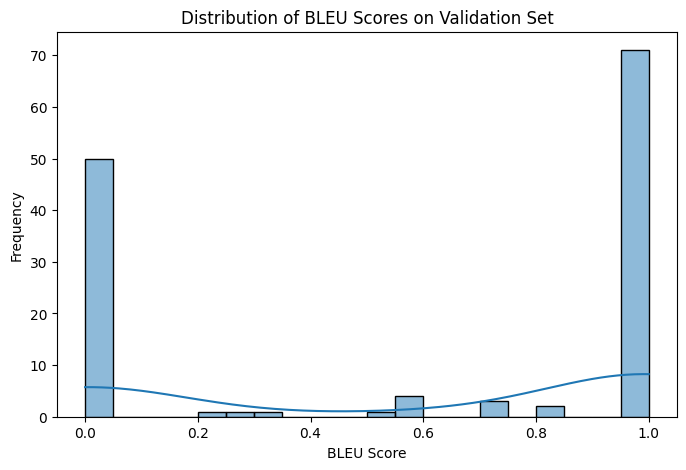

In [ ]:
import os
import random
import nltk
nltk.download("wordnet")

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from transformers import (
    BertTokenizer,
    AutoProcessor,
    BlipForConditionalGeneration,
)

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score

# -------------------------------------------------------------------
# Config
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMG_DIRS = [
    "/content/drive/MyDrive/ChinaSet_AllFiles/diseased",
    "/content/drive/MyDrive/ChinaSet_AllFiles/normal",
]

MAX_LENGTH = 30
BATCH_SIZE = 4
EPOCHS = 10
LR = 1e-5

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# -------------------------------------------------------------------
# Helpers for file layout
# -------------------------------------------------------------------
def img_to_txt_path(img_path: str) -> str:
    return img_path.replace(".png", ".txt")


def load_caption(txt_path: str) -> str:
    with open(txt_path, "r", encoding="utf-8") as f:
        lines = [line.strip().lower() for line in f.readlines()[1:]]
    return ". ".join(lines).strip(". ")

# -------------------------------------------------------------------
# Dataset (only need ImageCaptionDataset for training BLIP)
# -------------------------------------------------------------------
class ImageCaptionDataset(Dataset):
    def __init__(self, img_paths):
        self.img_paths = img_paths
        self.transform = img_transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        txt_path = img_to_txt_path(img_path)

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        caption = load_caption(txt_path)
        token = tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        return image, token["input_ids"].squeeze(0), token["attention_mask"].squeeze(0), caption, img_path

# -------------------------------------------------------------------
# Data split (only for BLIP training/eval)
# -------------------------------------------------------------------
all_image_paths = []
for img_dir in IMG_DIRS:
    all_image_paths.extend(
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.endswith(".png")
    )

normal_images = [p for p in all_image_paths if p.endswith("_0.png")]
diseased_images = [p for p in all_image_paths if p.endswith("_1.png")]

normal_train, normal_val = train_test_split(normal_images, test_size=0.2, random_state=42)
diseased_train, diseased_val = train_test_split(diseased_images, test_size=0.2, random_state=42)

train_paths = normal_train + diseased_train
val_paths = normal_val + diseased_val

random.shuffle(train_paths)
random.shuffle(val_paths)

caption_train_dataset = ImageCaptionDataset(train_paths)
caption_train_loader = DataLoader(
    caption_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

val_dataset_for_eval = ImageCaptionDataset(val_paths)
val_loader = DataLoader(
    val_dataset_for_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

# -------------------------------------------------------------------
# BLIP captioner (pretrained) – image–text relationship
# -------------------------------------------------------------------
blip_model_name = "Salesforce/blip-image-captioning-base"
blip_processor = AutoProcessor.from_pretrained(blip_model_name)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_model_name).to(device)  # [web:6][web:37]

# Fine-tune BLIP for MAX_LENGTH-limited reports
blip_model.train()
optimizer_cap = torch.optim.Adam(blip_model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for images, input_ids, attn_mask, captions, _ in tqdm(
        caption_train_loader, desc=f"BLIP Epoch {epoch+1}"
    ):
        images = images.to(device)

        # Convert batch of tensors to list of PIL images for BLIP processor
        pil_images = [transforms.ToPILImage()(img.cpu()) for img in images]

        # Teacher-forced training using ground-truth reports
        blip_inputs = blip_processor(
            images=pil_images,
            text=list(captions),
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)

        output = blip_model(
            input_ids=blip_inputs.input_ids,
            attention_mask=blip_inputs.attention_mask,
            pixel_values=blip_inputs.pixel_values,
            labels=blip_inputs.input_ids,
        )

        loss = output.loss
        optimizer_cap.zero_grad()
        loss.backward()
        optimizer_cap.step()

        epoch_loss += loss.item()

    print(f"BLIP Epoch {epoch+1} Loss: {epoch_loss / len(caption_train_loader):.4f}")

torch.save(blip_model.state_dict(), "/content/drive/MyDrive/blip_captioner_finetuned.pth")
print("BLIP model saved!")

# -------------------------------------------------------------------
# Evaluation: generate reports, compute BLEU/METEOR/ROUGE
# -------------------------------------------------------------------
blip_model.eval()

results = []
bleu_scores = []
meteor_scores_list = []
rouge_1 = []
rouge_2 = []
rouge_l = []

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

print("\nEvaluating on validation set (val_loader)...")

for images, _, _, _, paths in tqdm(val_loader):
    for i in range(images.size(0)):
        path = paths[i]

        # Prepare PIL image for BLIP
        pil_img = Image.open(path).convert("RGB")

        # BLIP generation (unconditional on text, only image) [web:6][web:8]
        blip_inputs = blip_processor(images=pil_img, return_tensors="pt").to(device)
        out_ids = blip_model.generate(
            **blip_inputs,
            max_length=MAX_LENGTH,
            num_beams=3,
            early_stopping=True,
        )
        pred_caption = blip_processor.batch_decode(
            out_ids, skip_special_tokens=True
        )[0].strip()

        # Ground truth caption
        caption_path = img_to_txt_path(path)
        gt_caption = load_caption(caption_path)

        # N-gram metrics
        ref = gt_caption.split()
        hyp = pred_caption.split()

        if len(ref) < 2 or len(hyp) < 2:
            bleu = sentence_bleu([ref], hyp, weights=(1.0,))
        else:
            bleu = sentence_bleu([ref], hyp, weights=(0.5, 0.5))
        meteor = meteor_score([ref], hyp)
        rouge = scorer.score(gt_caption, pred_caption)

        bleu_scores.append(bleu)
        meteor_scores_list.append(meteor)
        rouge_1.append(rouge["rouge1"].fmeasure)
        rouge_2.append(rouge["rouge2"].fmeasure)
        rouge_l.append(rouge["rougeL"].fmeasure)

        results.append({
            "ImagePath": path,
            "GroundTruthReport": gt_caption,
            "GeneratedReport": pred_caption,
            "BLEU": bleu,
            "METEOR": meteor,
            "ROUGE-1": rouge["rouge1"].fmeasure,
            "ROUGE-2": rouge["rouge2"].fmeasure,
            "ROUGE-L": rouge["rougeL"].fmeasure,
        })

# Save results
df = pd.DataFrame(results)
df.to_csv(
    "/content/drive/MyDrive/report_generation_results_blip_only.csv",
    index=False,
)
print("Results saved.")

# Aggregate metrics
print("\n📊 Validation Set Report Generation Metrics:")
print(f"Avg BLEU:     {sum(bleu_scores)/len(bleu_scores):.4f}")
print(f"Avg METEOR:   {sum(meteor_scores_list)/len(meteor_scores_list):.4f}")
print(f"Avg ROUGE-1:  {sum(rouge_1)/len(rouge_1):.4f}")
print(f"Avg ROUGE-2:  {sum(rouge_2)/len(rouge_2):.4f}")
print(f"Avg ROUGE-L:  {sum(rouge_l)/len(rouge_l):.4f}")

# BLEU histogram
plt.figure(figsize=(8, 5))
sns.histplot(bleu_scores, bins=20, kde=True)
plt.title("Distribution of BLEU Scores on Validation Set")
plt.xlabel("BLEU Score")
plt.ylabel("Frequency")
plt.savefig("/content/drive/MyDrive/bleu_score_distribution_blip_only.png")
plt.show()

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/report_generation_results_blip_only.csv")
df

,ImagePath,GroundTruthReport,GeneratedReport,BLEU,METEOR,ROUGE-1,ROUGE-2,ROUGE-L
0,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,normal,1.000000e+00,0.500000,1.000000,0.000000,1.000000
1,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,normal,1.000000e+00,0.500000,1.000000,0.000000,1.000000
2,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,normal,1.000000e+00,0.500000,1.000000,0.000000,1.000000
3,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,normal,1.000000e+00,0.500000,1.000000,0.000000,1.000000
4,/content/drive/MyDrive/ChinaSet_AllFiles/disea...,ptb in the left upper field,ptb in the right upper field,7.071068e-01,0.806667,0.833333,0.600000,0.833333
...,...,...,...,...,...,...,...,...
129,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,normal,1.000000e+00,0.500000,1.000000,0.000000,1.000000
130,/content/drive/MyDrive/ChinaSet_AllFiles/disea...,right ptb with fibrous changes,bilateral ptb,2.353507e-155,0.106383,0.285714,0.000000,0.285714
131,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,normal,1.000000e+00,0.500000,1.000000,0.000000,1.000000
132,/content/drive/MyDrive/ChinaSet_AllFiles/norma...,normal,ptb in the right upper field,0.000000e+00,0.000000,0.000000,0.000000,0.000000


In [ ]:
%pip install spacy benepar radgraph

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.0/588.0 kB 24.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for benepar: filename=benepar-0.2.0-py3-none-any.whl size=37625 sha256=de1c6b120b79717e3b18226dce2cd1b174cf0c443d844383db5e9882fe4ee8a5
  Stored in directory: /root/.cache/pip/wheels/9b/84/c1/f2ac877f519e2864e7dfe52a1c17fe5cdd50819cb8d1f1945f
  Created wheel for radgraph: filename=radgraph-0.1.18-py3-none-any.whl size=812635 sha256=b75a77e808b96b1cafb029ccefc8bd484564762b06b5b27cc5695616f3be0ad4
  Stored in directory: /root/.cache/pip/wheels/fb/3c/fb/214f5d5cdab2a0f9f0904fd81d7fd1134404100b4444554df8
Successfully built benepar radgraph


In [ ]:
generated_list = df['GeneratedReport'].tolist()
ground_truth_list = df['GroundTruthReport'].tolist()

In [ ]:
from radgraph import F1RadGraph
refs = ground_truth_list

hyps = generated_list
f1radgraph = F1RadGraph(reward_level="all", model_type="radgraph-xl")
mean_reward, reward_list, hypothesis_annotation_lists, reference_annotation_lists = f1radgraph(hyps=hyps, refs=refs)

rg_e, rg_er, rg_bar_er = mean_reward

print(mean_reward)

Using device: cuda:0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


radgraph-xl.tar.gz:   0%|          | 0.00/416M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/radgraph/radgraph.py:105: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=model_dir)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


tokenizer_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/radgraph/dygie/data/dataset_readers/dygie.py:189: UserWarning: Document 0 has a sentence with a single token or no tokens. This may break the modeling code.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/radgraph/dygie/data/dataset_readers/dygie.py:189: UserWarning: Document 1 has a sentence with a single token or no tokens. This may break the modeling code.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/radgraph/dygie/data/dataset_readers/dygie.py:189: UserWarning: Document 2 has a sentence with a single token or no tokens. This may break the modeling code.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/radgraph/dygie/data/dataset_readers/dygie.py:189: UserWarning: Document 3 has a sentence with a single token or no tokens. This may break the modeling code.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/radgraph/dygie/data/dataset_readers/dygie.py:189: UserWarning: Document 7 has a sentence

(np.float64(0.6691897654584222), np.float64(0.6424484719260839), np.float64(0.6424484719260839))
